In [77]:
#%pip install ase==3.22.1
#%pip install numpy==1.24.4
#%pip install dscribe==2.5.0
#%pip install scipy

In [78]:
from ase.io import read
from ase import Atoms
import os
import glob

folder_path = './Brownmillerite/'
file_list = sorted(glob.glob(os.path.join(folder_path, '*POSCAR'))) 

atoms_list = []
stype = []
red = 0
green = 0
blue = 0
for struc in file_list:
    if "3C" in struc:
        stype.append("red")
        red += 1
    elif "6H" in struc:
        stype.append("black") 
        green += 1
    elif "12R" in struc:
        stype.append("blue")  
        blue +=1
    else:
        print("Found undefind")
        break
    atoms = read(struc,format='vasp')
    atoms_list.append(atoms)
    #print(f"Loaded: {struc}")
n_struc = len(atoms_list)
print(f"Total files loaded: {n_struc}")
print(f"3C = {red}")
print(f"6H = {green}")
print(f"12R = {blue}")
print(f"stype loaded {len(stype)} items")


Found undefind
Total files loaded: 40398
3C = 28664
6H = 63
12R = 11671
stype loaded 40398 items


In [79]:
#Parameters setting
r_cut=5
n_max=2
l_max=2
print(atoms[0])

Atom('Sr', [3.4548621409840216e-08, -0.25944047007731696, 10.185116165385109], index=0)


In [80]:
species = list(set(atoms.get_chemical_symbols()))
print(species)

['Co', 'Sr', 'O']


# Create average vector for each substance

In [81]:
import numpy as np
from dscribe.descriptors import SOAP
from ase import Atoms

energy = []
soap_vectors = []
all_atoms = []

average_soap = SOAP(
    species=species,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
    average="inner",
    sparse=False,
    periodic=True
)

for cid in atoms_list:
    #print(cid)
    try:
        atoms = cid
    except KeyError:
        print(f"CID {cid} not found, skip")
        continue
    soap_vectors.append(average_soap.create(atoms))
    #all_atoms.append(atoms)
soap_array = np.array(soap_vectors)



# UMAP

In [82]:
import matplotlib.pyplot as plt

rcParams_dict = {
    # ---------- figure
    'figure.figsize': [8, 6],
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    # ---------- axes
    'axes.grid': True,
    'axes.linewidth': 1.5,
    # ---------- ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.major.size': 8.0,
    'ytick.major.size': 8.0,
    # ---------- lines
    'lines.linewidth': 2.5,
    'lines.markersize': 12,
    # ---------- grid
    'grid.linestyle': ':',
    # ---------- font
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'cm',
    #'mathtext.fontset': 'stix',
    'font.size': 15,
    'axes.labelsize': 20,
    'legend.fontsize': 20,
    'svg.fonttype': 'path',  # Embed characters as paths
    #'svg.fonttype': 'none',  # Assume fonts are installed on the machine
    'pdf.fonttype': 42,  # embed fonts in PDF using type42 (True type)
}

plt.rcParams.update(rcParams_dict)

/Users/kongkitimanon2024/.pyenv/versions/miniforge3-22.11.1-4/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kongkitimanon2024/.pyenv/versions/miniforge3-22.11.1-4/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/0f/_n97csts5c5c3ldj1k40vc100000gn/T/ipykernel_55212/3581693735.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(embedding[:, 0], embedding[:, 1], c=stype, cmap='Spectral', s=20)


(40398, 2)


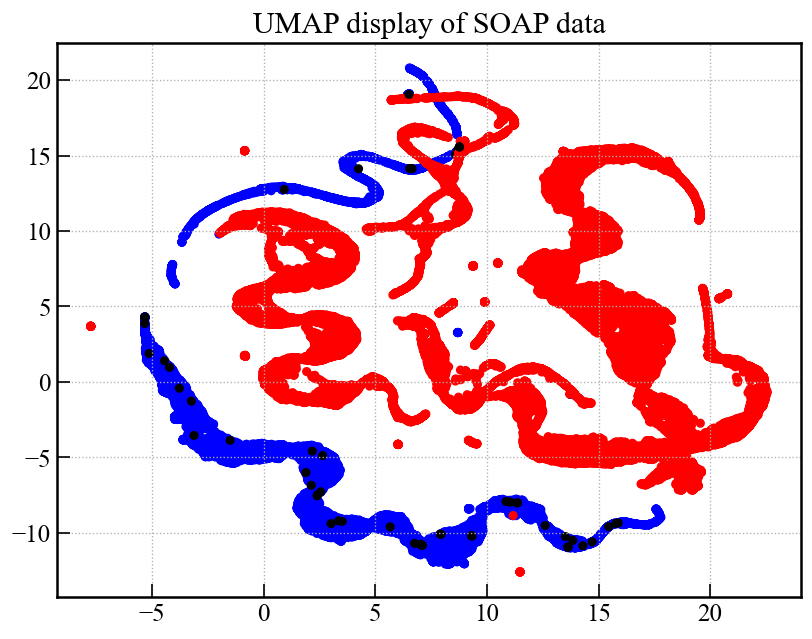

In [83]:
import umap
%matplotlib inline
import matplotlib.pyplot as plt
# umapで2次元に削減
reducer = umap.UMAP()
reducer.fit(soap_array)
embedding = reducer.transform(soap_array)
print(embedding.shape)

plt.scatter(embedding[:, 0], embedding[:, 1], c=stype, cmap='Spectral', s=20)
#plt.gca().set_aspect('equal', 'datalim')
# plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
# plt.colorbar(ticks=mticker.NullLocator())
#plt.colorbar()
plt.title('UMAP display of SOAP data')
plt.show()

/Users/kongkitimanon2024/.pyenv/versions/miniforge3-22.11.1-4/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/kongkitimanon2024/.pyenv/versions/miniforge3-22.11.1-4/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/var/folders/0f/_n97csts5c5c3ldj1k40vc100000gn/T/ipykernel_55212/2981815470.py:9: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(embedding[:, 0], embedding[:, 1],cmap='viridis', s=20)


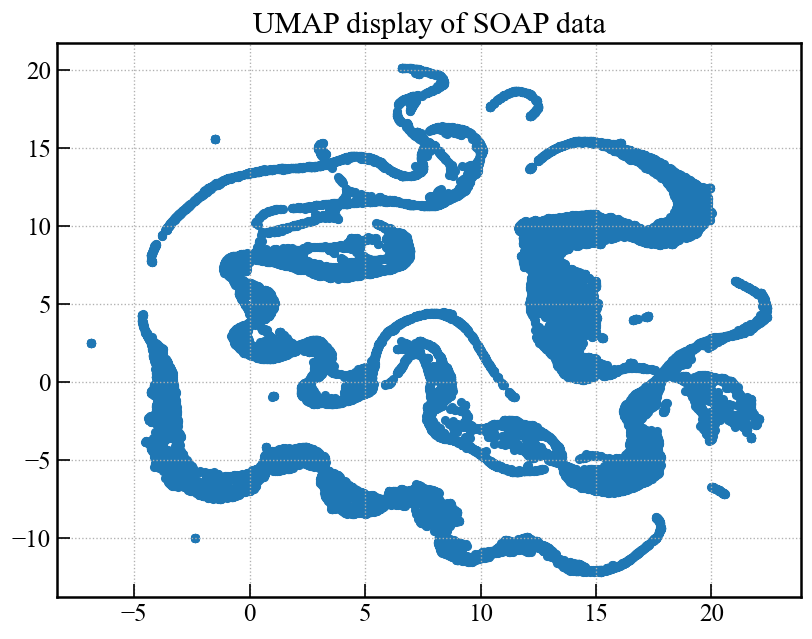

In [84]:
import umap
reducer = umap.UMAP()
reducer.fit(soap_array)
embedding = reducer.transform(soap_array)
#print(embedding.shape)

#plt.figure(figsize=(8, 6))
#sc = plt.scatter(embedding[:, 0], embedding[:, 1], c=energy, cmap='viridis', s=20)
plt.scatter(embedding[:, 0], embedding[:, 1],cmap='viridis', s=20)
#plt.xlim(-2,13)
#plt.ylim(-2,13)
#plt.colorbar(sc, label='Energy (eV/atom)')
plt.title('UMAP display of SOAP data')
#plt.legend()
plt.show()
#plt.colorbar()